# Reinforcement Learning - Individual Assignment
## Text Flappy Bird: GLIE Monte-Carlo Control & SARSA($\lambda$)

This notebook implements, trains and evaluates two tabular RL agents on the Text Flappy Bird environment:

| Agent | Algorithm | Key idea |
|---|---|---|
| **GLIE MC** | First-visit Monte-Carlo control | Full-return updates after each episode |
| **SARSA($\mathrm{\lambda}$)** | SARSA with accumulating eligibility traces | Online TD updates with trace decay |

**Outline:**
1. Environment Setup
2. GLIE Monte-Carlo Agent - definition, grid search, training on best params & evaluation
3. SARSA($\lambda$) Agent - definition, grid search, training on best params & evaluation
4. Direct Comparison - MC vs SARSA($\lambda$)
5. Configuration Generalization Analysis
6. Summary

In [ ]:
import os, sys, random
import gymnasium as gym
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm import tqdm
import time
import pickle
from pathlib import Path
from joblib import Parallel, delayed

import text_flappy_bird_gym

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150})

In [35]:
# Flags - set to True to retrain/resave agents
TRAIN_MC = True
SAVE_MC = True
TRAIN_SARSA = True
SAVE_SARSA = True

SAVE_FIG = True

In [36]:
mc_results_dir = Path.cwd().parent / 'results' / 'MC'
mc_results_dir.mkdir(parents=True, exist_ok=True)
mc_save_path = mc_results_dir / 'mc_agent.pkl'

sarsa_results_dir = Path.cwd().parent / 'results' / 'SARSA'
sarsa_results_dir.mkdir(parents=True, exist_ok=True)
sarsa_save_path = sarsa_results_dir / 'sarsa_lambda_agent.pkl'

---
## 1. Environment Setup

We use the simple-state variant `TextFlappyBird-v0` which returns `(x_distance, y_distance)` - the horizontal and vertical distance from the bird to the centre of the nearest pipe gap. The action space is `Discrete(2)`: **0 = idle** (do nothing), **1 = flap**.

In [37]:
# Initialise the environment (simple state: x_dist, y_dist)
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)

obs, info = env.reset()
print(f"Observation: {obs}")
print(f"Action space: {env.action_space}")  # Discrete(2)

Observation: (13, -2)
Action space: Discrete(2)


---
## 2. GLIE Monte-Carlo Control Agent

### 2.1 Agent Class

The agent maintains:
- **Q(s, a)**: action-value estimates (dictionary keyed by `(state, action)`)
- **N(s, a)**: visit counts for each state-action pair
- **$\epsilon$**: exploration rate, decayed to satisfy the GLIE condition

The $\epsilon$-greedy policy selects:
- the greedy action with probability $1 - \epsilon + \epsilon/m$
- each non-greedy action with probability $\epsilon/m$

where $m$ is the number of actions.

Three epsilon-decay schedules are supported: **linear**, **inverse** ($\epsilon = 1/k$), and **exponential**.

In [38]:
class GLIEMCAgent:
    """GLIE Monte-Carlo Control agent for Text Flappy Bird."""

    def __init__(self, n_actions: int = 2, min_epsilon: float = 0.01, max_epsilon: float = 1.0, decay_step: float = 0.0001, lambda_: float = 0.0001):
        self.n_actions = n_actions
        self.min_epsilon = min_epsilon
        self.max_epsilon = max_epsilon
        self.decay_step = decay_step    # for linear decay
        self.lambda_ = lambda_          # for exponential decay
        # Q-values and visit counts stored as dicts for sparse state space
        self.Q = defaultdict(float)         # (state, action) -> value
        self.N = defaultdict(int)           # (state, action) -> visit count
        self.epsilon = 1.0
        self.episode_count = 0

    # policy
    def get_action(self, state: tuple) -> int:
        """Select an action using the epsilon-greedy policy w.r.t. current Q."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        # greedy: pick action with highest Q (break ties randomly)
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best_actions)

    def greedy_action(self, state: tuple) -> int:
        """Purely greedy action (for evaluation)."""
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best_actions)

    # learning
    def update(self, episode: list[tuple], gamma: float = 1.0):
        """
        Update Q from a complete episode using first-visit MC.

        Parameters
        ----------
        episode : list of (state, action, reward) tuples
        gamma   : discount factor (1.0 for undiscounted)
        """
        G = 0.0
        visited = set()
        # Walk backwards through the episode
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward

            sa = (state, action)
            # First-visit: only update the first time we see (s, a)
            if sa not in visited:
                visited.add(sa)
                self.N[sa] += 1
                # Incremental mean update: Q ← Q + (1/N)(G - Q)
                self.Q[sa] += (1.0 / self.N[sa]) * (G - self.Q[sa])

    def decay_epsilon(self, n_episodes: int, decay_type: str = "linear"):
        """GLIE epsilon decay: linear decay over all training episodes."""
        self.episode_count += 1
        if decay_type == "inverse":
            self.epsilon = max(self.min_epsilon, 1.0 / self.episode_count)
        elif decay_type == "linear":
            self.epsilon = max(self.min_epsilon, self.max_epsilon - self.episode_count * self.decay_step)
        elif decay_type == "exponential":
            self.epsilon = self.min_epsilon + (self.max_epsilon - self.min_epsilon) * np.exp(- self.lambda_ * self.episode_count)

### 2.2 Training Loop

We run thousands of episodes. In each episode we:
1. Generate a full trajectory under the current $\epsilon$-greedy policy.
2. Compute returns and update $Q(s,a)$ (first-visit MC).
3. Decay $\epsilon$.

In [39]:
def train_mc(env, agent, n_episodes: int = 50_000, gamma: float = 1.0, log_every: int = 1000, decay_type: str = "linear"):
    """Train the GLIE MC agent and return training statistics."""
    reward_history = []     # total reward per episode
    avg_rewards = []        # running average (over last `log_every` episodes)
    epsilon_history = []
    print(f"Starting MC training with {n_episodes} episodes, gamma={gamma}, decay_type={decay_type}")
    for k in tqdm(range(1, n_episodes + 1), desc="Training MC"):
        # Generate an episode
        obs, _ = env.reset()
        state = tuple(obs)
        episode = []
        total_reward = 0.0

        done = False
        while not done:
            action = agent.get_action(state)
            next_obs, reward, done, _, info = env.step(action)
            episode.append((state, action, reward))
            total_reward += reward
            state = tuple(next_obs)

        # Update Q-values
        agent.update(episode, gamma=gamma)

        # Decay epsilon (GLIE)
        agent.decay_epsilon(n_episodes, decay_type=decay_type)

        # Logging
        reward_history.append(total_reward)
        epsilon_history.append(agent.epsilon)

        if k % log_every == 0:
            avg_r = np.mean(reward_history[-log_every:])
            avg_rewards.append(avg_r)
            print(f"Episode {k:>7d} | Avg reward (last {log_every}): {avg_r:7.2f} "
                  f"| \u03b5: {agent.epsilon:.5f} | Q-table size: {len(agent.Q)}")

    return reward_history, avg_rewards, epsilon_history

### 2.3 Evaluation Function

Shared evaluation utility used by both grid search and final evaluation.
Episodes are capped at `max_steps = 5000` to avoid infinite runs from well-trained agents.

In [40]:
def evaluate(env, agent, n_episodes: int = 1000, max_steps: int = 5000):
    """Evaluate the agent using a purely greedy policy (no exploration)."""
    total_rewards = []
    for _ in tqdm(range(n_episodes), desc="Evaluating"):
        obs, _ = env.reset()
        state = tuple(obs)
        total_reward = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = agent.greedy_action(state)
            obs, reward, done, _, info = env.step(action)
            state = tuple(obs)
            total_reward += reward
            steps += 1
        total_rewards.append(total_reward)
    return total_rewards

### 2.4 Hyperparameter Grid Search

We perform a grid search over decay types and their associated parameters to find
the configuration that maximises mean greedy reward after a fixed training budget.

Each configuration is trained for $10\,000$ episodes (a reduced budget for
tractability) and evaluated greedily over $500$ episodes. Configurations are
trained in parallel using `joblib`.

| Decay type | Parameter swept |
|---|---|
| `inverse`     | - |
| `linear`      | `decay_step` |
| `exponential` | `lambda_` |

`min_epsilon` is also swept across all types.

The best configuration found is then used for the full $50\,000$-episode training run.

In [41]:
# Grid definition
MC_GS_EPISODES = 10_000  # training budget per config
MC_GS_EVAL_EPS = 500     # greedy evaluation episodes per run
MC_GS_GAMMA    = 0.99

mc_min_epsilons = [0.01, 0.05]
mc_decay_steps  = [0.001, 0.005]   # linear
mc_lambdas      = [0.0005, 0.001]  # exponential

# Build list of (label, decay_type, agent_kwargs)
mc_grid = []

for me in mc_min_epsilons:
    mc_grid.append((f"inverse | min_\u03b5={me}", "inverse",
                    dict(min_epsilon=me)))

for me in mc_min_epsilons:
    for ds in mc_decay_steps:
        mc_grid.append((f"linear | step={ds} | min_\u03b5={me}", "linear",
                        dict(min_epsilon=me, decay_step=ds)))

for me in mc_min_epsilons:
    for lm in mc_lambdas:
        mc_grid.append((f"exponential | \u03bb={lm} | min_\u03b5={me}", "exponential",
                        dict(min_epsilon=me, lambda_=lm)))

print(f"MC grid - Total configurations: {len(mc_grid)}")
print(f"Total training episodes: {len(mc_grid) * MC_GS_EPISODES:,}")

MC grid - Total configurations: 10
Total training episodes: 100,000


In [42]:
def _mc_train_and_eval(label, decay_type, kwargs):
    """Train one MC config and return its evaluation result."""
    import text_flappy_bird_gym  # must register env in worker process
    gs_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
    gs_agent = GLIEMCAgent(n_actions=gs_env.action_space.n, **kwargs)

    for _ in range(1, MC_GS_EPISODES + 1):
        obs, _ = gs_env.reset()
        state = tuple(obs)
        episode = []
        done = False
        while not done:
            action = gs_agent.get_action(state)
            next_obs, reward, done, _, _ = gs_env.step(action)
            episode.append((state, action, reward))
            state = tuple(next_obs)
        gs_agent.update(episode, gamma=MC_GS_GAMMA)
        gs_agent.decay_epsilon(MC_GS_EPISODES, decay_type=decay_type)

    # Evaluate
    rewards = evaluate(gs_env, gs_agent, n_episodes=MC_GS_EVAL_EPS)
    return {"label": label, "decay_type": decay_type, "kwargs": kwargs,
            "mean_reward": np.mean(rewards), "std_reward": np.std(rewards)}

# Run all configs in parallel
mc_gs_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(_mc_train_and_eval)(label, decay_type, kwargs)
    for label, decay_type, kwargs in mc_grid
)

mc_gs_results.sort(key=lambda r: r["mean_reward"], reverse=True)
print("\nTop 10 MC configurations:")
print(f"{'Rank':<5} {'Mean Reward':>12} {'Std':>8}  Label")
print("-" * 75)
for i, r in enumerate(mc_gs_results[:10], 1):
    print(f"{i:<5} {r['mean_reward']:>12.2f} {r['std_reward']:>8.2f}  {r['label']}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:  1.1min remaining:  2.6min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:  1.6min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  1.8min remaining:   45.3s



Top 10 MC configurations:
Rank   Mean Reward      Std  Label
---------------------------------------------------------------------------
1          5000.00     0.00  exponential | λ=0.0005 | min_ε=0.05
2          2247.68  1690.21  exponential | λ=0.0005 | min_ε=0.01
3          1627.78  1444.89  linear | step=0.001 | min_ε=0.01
4          1608.47  1420.68  linear | step=0.005 | min_ε=0.05
5           837.17   766.79  inverse | min_ε=0.01
6           737.31   704.11  exponential | λ=0.001 | min_ε=0.05
7           458.03   431.66  exponential | λ=0.001 | min_ε=0.01
8           355.48   356.44  linear | step=0.001 | min_ε=0.05
9           202.52   176.64  inverse | min_ε=0.05
10           99.74   127.12  linear | step=0.005 | min_ε=0.01


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  2.7min finished


C:\Users\adoni\AppData\Local\Temp\ipykernel_12584\1687374375.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(decay_groups.values(), labels=decay_groups.keys(), patch_artist=True,


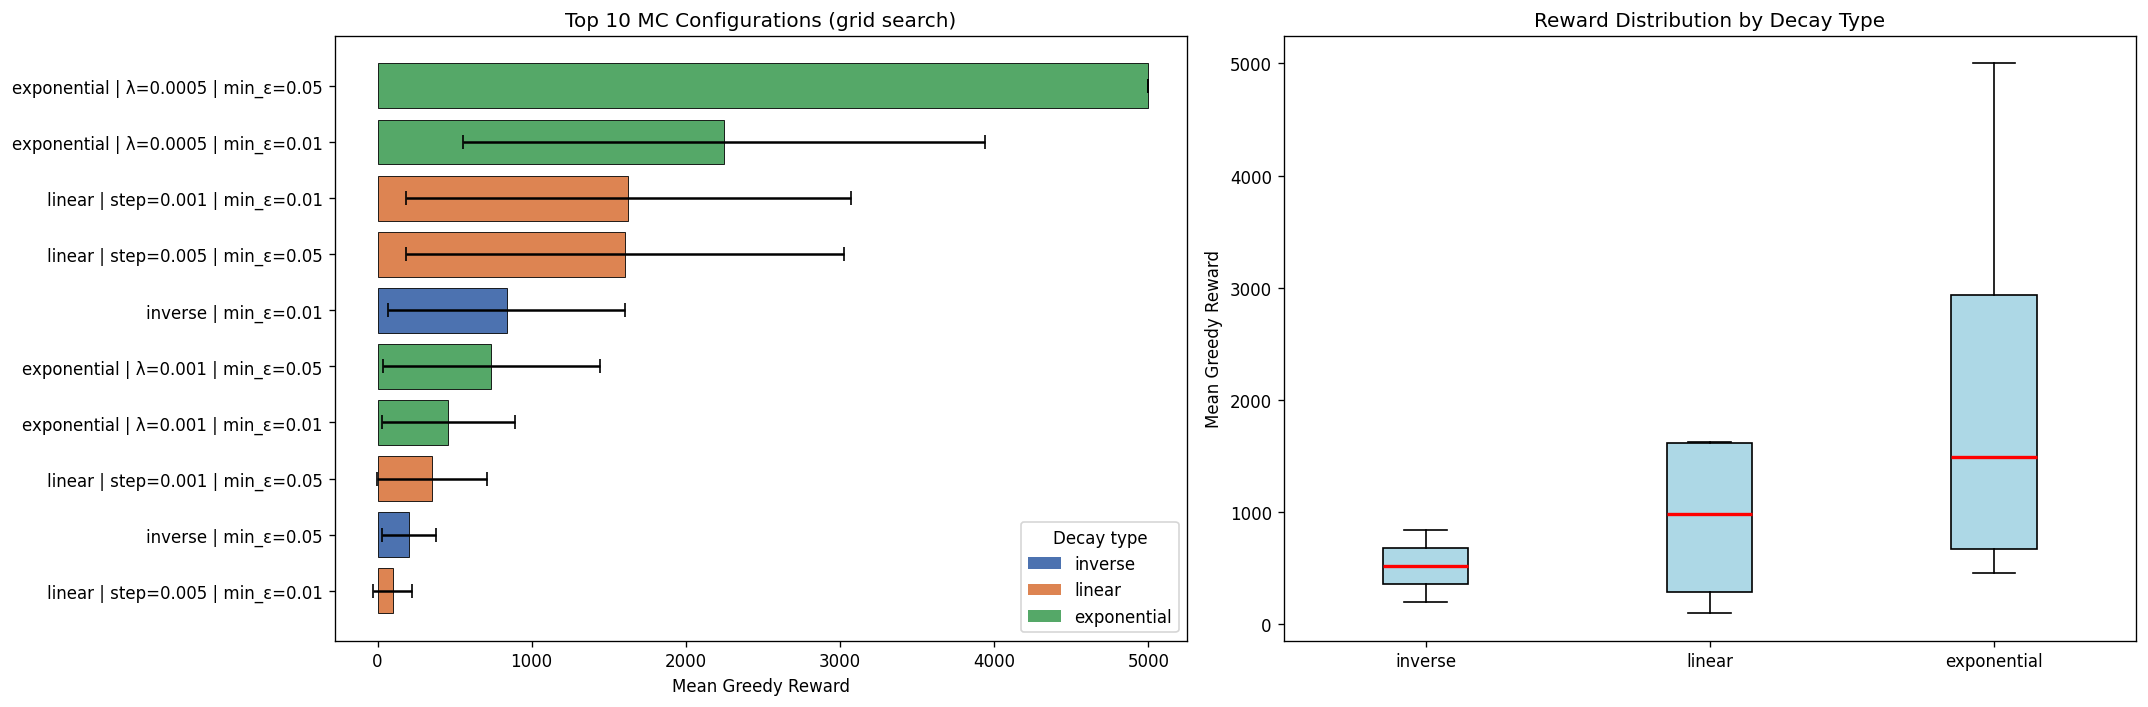


Best MC configuration found:
    Decay type : exponential
    Parameters : {'min_epsilon': 0.05, 'lambda_': 0.0005}
    Mean reward: 5000.00 ± 0.00


In [43]:
# Visualise MC grid search results
mc_gs_df = pd.DataFrame(mc_gs_results)

top_n = min(15, len(mc_gs_df))
mc_gs_top = mc_gs_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

mc_colors = {"inverse": "#4C72B0", "linear": "#DD8452", "exponential": "#55A868"}
bar_colors = [mc_colors[dt] for dt in mc_gs_top["decay_type"]]

axes[0].barh(mc_gs_top["label"][::-1], mc_gs_top["mean_reward"][::-1],
             xerr=mc_gs_top["std_reward"][::-1], color=bar_colors[::-1],
             capsize=4, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Mean Greedy Reward")
axes[0].set_title(f"Top {top_n} MC Configurations (grid search)")
legend_elements = [Patch(facecolor=c, label=l) for l, c in mc_colors.items()]
axes[0].legend(handles=legend_elements, title="Decay type", loc="lower right")

# Mean reward by decay type
decay_groups = {dt: mc_gs_df[mc_gs_df["decay_type"] == dt]["mean_reward"].values
                for dt in ["inverse", "linear", "exponential"]}
axes[1].boxplot(decay_groups.values(), labels=decay_groups.keys(), patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Mean Greedy Reward")
axes[1].set_title("Reward Distribution by Decay Type")

plt.tight_layout()
if SAVE_FIG: plt.savefig(mc_results_dir / 'gridsearch_results.png', dpi=150, bbox_inches='tight')
plt.show()

mc_best = mc_gs_results[0]
print("\nBest MC configuration found:")
print(f"    Decay type : {mc_best['decay_type']}")
print(f"    Parameters : {mc_best['kwargs']}")
print(f"    Mean reward: {mc_best['mean_reward']:.2f} \u00b1 {mc_best['std_reward']:.2f}")

### 2.5 Training on Best Parameters

We use the best hyperparameters identified by the grid search to train the MC agent
for the full $50\,000$-episode budget.

In [44]:
# Use best parameters found by grid search
mc_best = mc_gs_results[0]
MC_N_EPISODES = 50_000
MC_GAMMA = 0.99
MC_DECAY_TYPE = mc_best['decay_type']

mc_best_kwargs = mc_best['kwargs']
MC_MIN_EPSILON = mc_best_kwargs.get('min_epsilon', 0.05)
MC_MAX_EPSILON = 1.0
MC_DECAY_STEP = mc_best_kwargs.get('decay_step', 0.005)
MC_LAMBDA = mc_best_kwargs.get('lambda_', 0.001)

# Create agent with best hyperparameters
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
mc_agent = GLIEMCAgent(
    n_actions=env.action_space.n,
    min_epsilon=MC_MIN_EPSILON,
    max_epsilon=MC_MAX_EPSILON,
    decay_step=MC_DECAY_STEP,
    lambda_=MC_LAMBDA,
)

print(f"Training with best grid-search config: {mc_best['label']}")
print(f"  Decay type : {MC_DECAY_TYPE}")
print(f"  Parameters : {mc_best_kwargs}")
print(f"  GS reward  : {mc_best['mean_reward']:.2f} \u00b1 {mc_best['std_reward']:.2f}")

Training with best grid-search config: exponential | λ=0.0005 | min_ε=0.05
  Decay type : exponential
  Parameters : {'min_epsilon': 0.05, 'lambda_': 0.0005}
  GS reward  : 5000.00 ± 0.00


In [45]:
if TRAIN_MC:
    mc_reward_history, mc_avg_rewards, mc_epsilon_history = train_mc(
        env, mc_agent, n_episodes=MC_N_EPISODES, gamma=MC_GAMMA, decay_type=MC_DECAY_TYPE
    )
    if SAVE_MC:
        with open(mc_save_path, 'wb') as f:
            pickle.dump({'Q': dict(mc_agent.Q), 'N': dict(mc_agent.N),
                         'epsilon': mc_agent.epsilon, 'episode_count': mc_agent.episode_count}, f)
        print(f"MC agent saved to {mc_save_path}")
else:
    if mc_save_path.exists():
        with open(mc_save_path, 'rb') as f:
            data = pickle.load(f)
        mc_agent.Q = defaultdict(float, data['Q'])
        mc_agent.N = defaultdict(int, data['N'])
        mc_agent.epsilon = data['epsilon']
        mc_agent.episode_count = data['episode_count']
        print(f"MC agent loaded from {mc_save_path}")
    else:
        print(f"No saved agent found at {mc_save_path}. Set TRAIN_MC = True to train.")

Starting MC training with 50000 episodes, gamma=0.99, decay_type=exponential


Training MC:   2%|▏         | 1100/50000 [00:00<00:19, 2484.35it/s]

Episode    1000 | Avg reward (last 1000):   14.58 | ε: 0.62620 | Q-table size: 528


Training MC:   4%|▍         | 2147/50000 [00:01<00:32, 1488.77it/s]

Episode    2000 | Avg reward (last 1000):   23.61 | ε: 0.39949 | Q-table size: 538


...

Episode   48000 | Avg reward (last 1000):  125.91 | ε: 0.05000 | Q-table size: 548


Training MC:  98%|█████████▊| 49042/50000 [02:49<00:04, 228.19it/s]

Episode   49000 | Avg reward (last 1000):  137.57 | ε: 0.05000 | Q-table size: 548


Training MC: 100%|██████████| 50000/50000 [02:53<00:00, 288.32it/s]

Episode   50000 | Avg reward (last 1000):  120.45 | ε: 0.05000 | Q-table size: 548
MC agent saved to c:\Users\adoni\Desktop\Reinforcement Learning\MDS-RL\individual assignment\results\MC\mc_agent.pkl


### 2.6 Training Curves

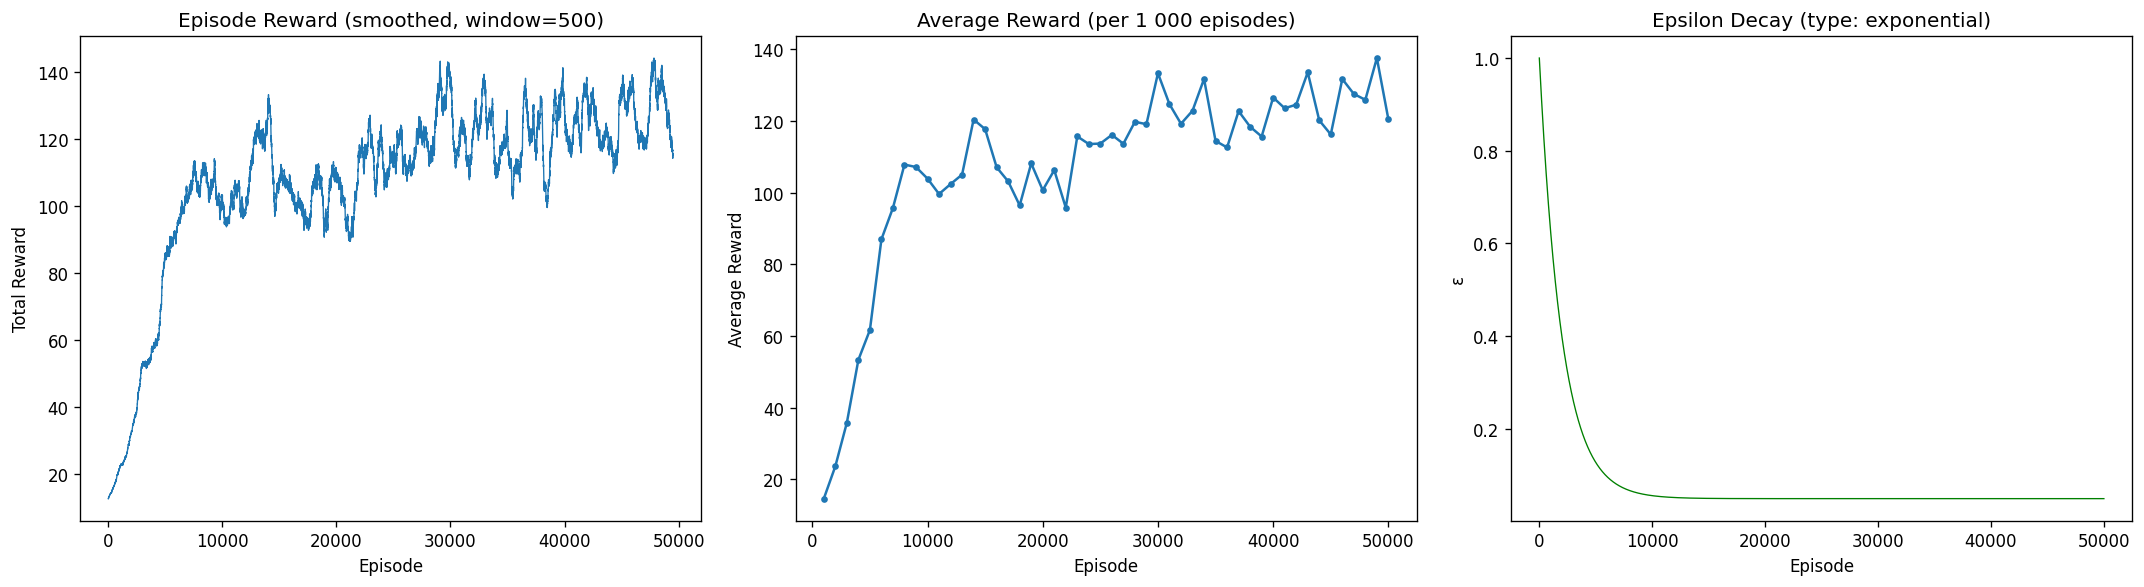

In [46]:
if TRAIN_MC:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Episode reward (smoothed)
    window = 500
    smoothed = np.convolve(mc_reward_history, np.ones(window)/window, mode='valid')
    axes[0].plot(smoothed, linewidth=0.8)
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Reward')
    axes[0].set_title(f'Episode Reward (smoothed, window={window})')

    # Average reward per logging interval
    axes[1].plot(range(1000, MC_N_EPISODES + 1, 1000), mc_avg_rewards, marker='o', markersize=3)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Average Reward')
    axes[1].set_title('Average Reward (per 1 000 episodes)')

    # Epsilon decay
    axes[2].plot(mc_epsilon_history, linewidth=0.8, color='green')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('\u03b5')
    axes[2].set_title(f'Epsilon Decay (type: {MC_DECAY_TYPE})')

    plt.tight_layout()
    if SAVE_FIG: plt.savefig(mc_results_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Training curves only available when TRAIN_MC = True.")

### 2.7 Evaluation (Greedy Policy)

Run the fully trained MC agent (greedy, $\epsilon = 0$) for several episodes to measure its average performance.

Evaluating: 100%|██████████| 1000/1000 [00:55<00:00, 18.18it/s]


MC Greedy evaluation over 1 000 episodes:
    Mean reward: 1859.69
    Std reward : 1555.75
    Max reward : 5000
    Min reward : 18


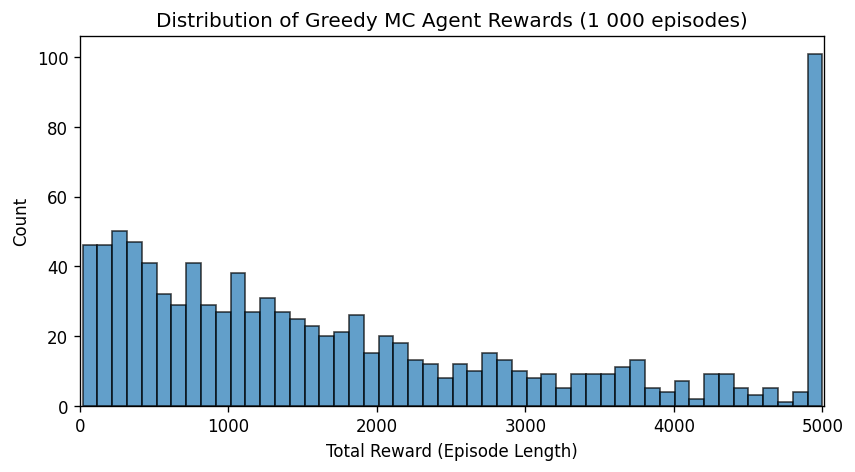

In [47]:
mc_eval_rewards = evaluate(env, mc_agent, n_episodes=1000)
print(f"MC Greedy evaluation over 1 000 episodes:")
print(f"    Mean reward: {np.mean(mc_eval_rewards):.2f}")
print(f"    Std reward : {np.std(mc_eval_rewards):.2f}")
print(f"    Max reward : {np.max(mc_eval_rewards):.0f}")
print(f"    Min reward : {np.min(mc_eval_rewards):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(mc_eval_rewards, bins=50, edgecolor='black', alpha=0.7)
plt.xlim(0, max(mc_eval_rewards) + 10)
plt.xlabel('Total Reward (Episode Length)')
plt.ylabel('Count')
plt.title('Distribution of Greedy MC Agent Rewards (1 000 episodes)')
if SAVE_FIG: plt.savefig(mc_results_dir / 'evaluation_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.8 State-Value Function

The state-value function $V(s) = \max_a Q(s,a)$ summarises how valuable each state is under the learned greedy policy. Since the state is a 2D tuple $(x_\text{dist}, y_\text{dist})$, we visualise $V$ as a heatmap.

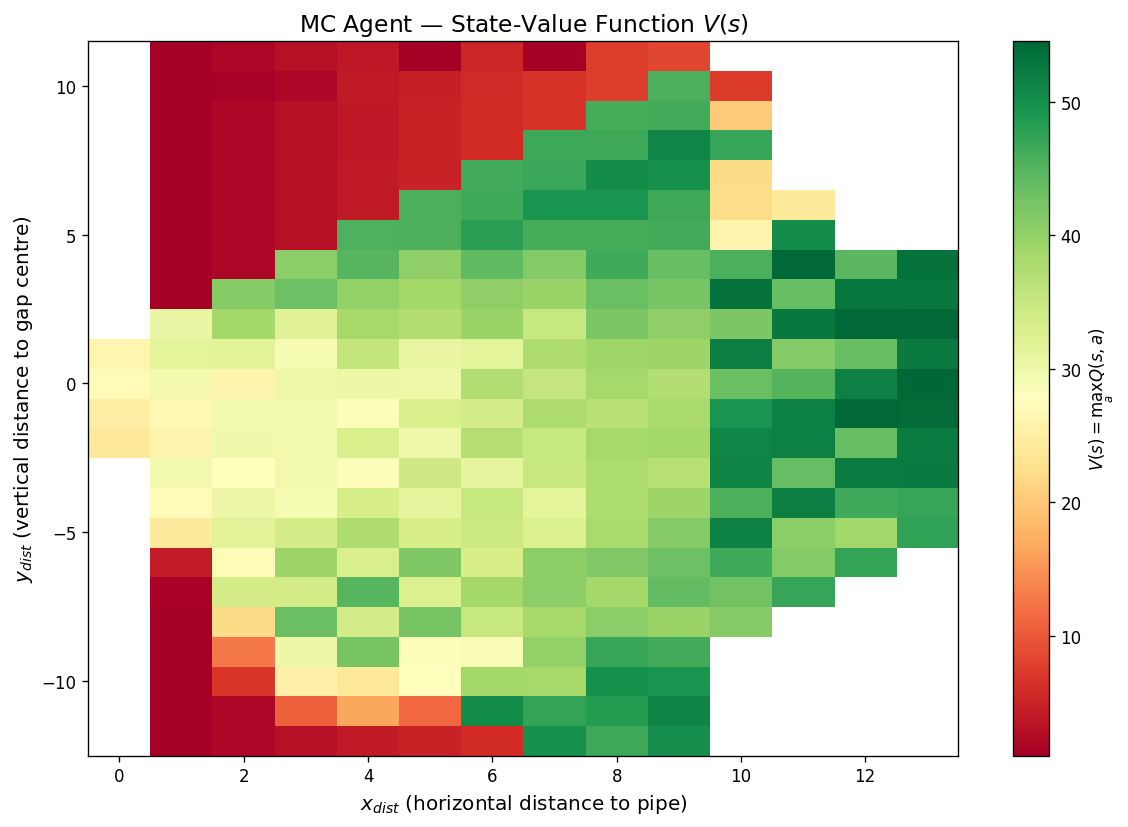

In [48]:
def plot_state_value_function(agent, title="State-Value Function", save_path=None):
    """Plot V(s) = max_a Q(s,a) as a 2D heatmap from the agent's Q-table."""
    # Extract all states from Q-table
    states = set()
    for (s, a) in agent.Q:
        states.add(s)

    if not states:
        print("Q-table is empty — nothing to plot.")
        return

    # Compute V(s) = max_a Q(s,a)
    V = {}
    for s in states:
        V[s] = max(agent.Q[(s, a)] for a in range(agent.n_actions))

    x_vals = sorted(set(s[0] for s in states))
    y_vals = sorted(set(s[1] for s in states))

    # Build grid (NaN for unvisited cells)
    grid = np.full((len(y_vals), len(x_vals)), np.nan)
    x_idx = {x: i for i, x in enumerate(x_vals)}
    y_idx = {y: i for i, y in enumerate(y_vals)}
    for s, v in V.items():
        grid[y_idx[s[1]], x_idx[s[0]]] = v

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='RdYlGn',
                   extent=[min(x_vals)-0.5, max(x_vals)+0.5,
                           min(y_vals)-0.5, max(y_vals)+0.5])
    ax.set_xlabel('$x_{dist}$ (horizontal distance to pipe)', fontsize=12)
    ax.set_ylabel('$y_{dist}$ (vertical distance to gap centre)', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.colorbar(im, ax=ax, label='$V(s) = \\max_a Q(s,a)$')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_state_value_function(mc_agent, title="MC Agent — State-Value Function $V(s)$",
                          save_path=mc_results_dir / 'state_value_function.png' if SAVE_FIG else None)

---
## 3. SARSA($\lambda$) Agent

### 3.1 Agent Class

SARSA($\lambda$) extends the one-step SARSA update with **eligibility traces**, which propagate the TD error backwards to all recently visited state-action pairs in a single pass.

**Key parameters:**
- $\alpha$ - step-size (learning rate)
- $\gamma$ - discount factor
- $\lambda$ - trace-decay parameter ($\lambda = 0$ gives one-step SARSA;
  $\lambda = 1$ gives Monte-Carlo-like behaviour)
- $\epsilon$ - exploration rate, decayed via GLIE: $\epsilon = 1/k$

**Per-step update (accumulating traces):**

$$\delta_t = R_{t+1} + \gamma \, Q(S', A') - Q(S, A)$$
$$E(S, A) \leftarrow E(S, A) + 1$$
$$\forall (s,a): \quad Q(s,a) \leftarrow Q(s,a) + \alpha \, \delta_t \, E(s,a)$$
$$\forall (s,a): \quad E(s,a) \leftarrow \gamma \, \lambda \, E(s,a)$$

In [49]:
class SarsaLambdaAgent:
    """SARSA(lambda) agent with accumulating eligibility traces for Text Flappy Bird."""

    def __init__(
        self,
        n_actions: int = 2,
        alpha: float = 0.1,
        gamma: float = 1.0,
        lambd: float = 0.8,
        min_epsilon: float = 0.01,
    ):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lambd = lambd
        self.min_epsilon = min_epsilon

        self.Q = defaultdict(float)   # (state, action) -> value
        self.epsilon = 1.0
        self.episode_count = 0

    # policy
    def get_action(self, state: tuple) -> int:
        """\u03b5-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best)

    def greedy_action(self, state: tuple) -> int:
        """Purely greedy action (for evaluation)."""
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best)

    # learning (one full episode)
    def run_episode(self, env) -> float:
        """
        Play one episode with SARSA(lambda) updates (accumulating traces).

        Returns the total undiscounted reward collected in the episode.
        """
        # Reset eligibility traces at the start of every episode
        E = defaultdict(float)

        obs, _ = env.reset()
        S = tuple(obs)
        A = self.get_action(S)
        total_reward = 0.0

        done = False
        while not done:
            obs_next, reward, done, _, info = env.step(A)
            total_reward += reward
            S_next = tuple(obs_next)

            if done:
                # Terminal step: Q(terminal, \u00b7) = 0, so TD target is just R
                delta = reward - self.Q[(S, A)]
            else:
                A_next = self.get_action(S_next)
                delta = reward + self.gamma * self.Q[(S_next, A_next)] - self.Q[(S, A)]

            # Accumulating trace for the current (S, A)
            E[(S, A)] += 1.0

            # Update all Q-values that have non-zero traces
            for sa in list(E.keys()):
                self.Q[sa] += self.alpha * delta * E[sa]
                E[sa] *= self.gamma * self.lambd
                # Remove negligible traces to keep the dict small
                if E[sa] < 1e-6:
                    del E[sa]

            if not done:
                S = S_next
                A = A_next

        return total_reward

    # epsilon decay
    def decay_epsilon(self):
        """GLIE epsilon decay: epsilon = 1/k, floored at min_epsilon."""
        self.episode_count += 1
        self.epsilon = max(self.min_epsilon, 1.0 / self.episode_count)

### 3.2 Training Loop

We run thousands of episodes. In each episode we:
1. Run a full episode with online SARSA(λ) updates (eligibility traces propagate
   the TD error to all recently visited state-action pairs).
2. Decay $\epsilon \leftarrow 1/k$ (GLIE).

In [50]:
def train_sarsa(env, agent, n_episodes: int = 50_000, log_every: int = 1000):
    """Train the SARSA(lambda) agent and return training statistics."""
    reward_history = []
    avg_rewards = []
    epsilon_history = []

    for k in tqdm(range(1, n_episodes + 1), desc="Training SARSA(\u03bb)"):
        total_reward = agent.run_episode(env)
        agent.decay_epsilon()

        reward_history.append(total_reward)
        epsilon_history.append(agent.epsilon)

        if k % log_every == 0:
            avg_r = np.mean(reward_history[-log_every:])
            avg_rewards.append(avg_r)
            print(f"Episode {k:>7d} | Avg reward (last {log_every}): {avg_r:7.2f} "
                  f"| \u03b5: {agent.epsilon:.5f} | Q-table size: {len(agent.Q)}")

    return reward_history, avg_rewards, epsilon_history

### 3.3 Hyperparameter Grid Search

We sweep the key SARSA($\lambda$) hyperparameters. The epsilon decay is fixed to the GLIE inverse schedule ($\epsilon = 1/k$); the more impactful hyperparameters are the step-size $\alpha$ and trace-decay $\lambda$.

| Parameter | Values swept |
|---|---|
| $\alpha$ (step-size) | 0.05, 0.1, 0.2 |
| $\lambda$ (trace decay) | 0.6, 0.8, 0.9 |
| `min_epsilon` | 0.01, 0.05 |

The best configuration found is then used for the full $50\,000$-episode training run.

In [51]:
# Grid definition
SARSA_GS_EPISODES = 10_000
SARSA_GS_EVAL_EPS = 500
SARSA_GS_GAMMA    = 0.99

sarsa_alphas       = [0.05, 0.1, 0.2]
sarsa_lambds       = [0.6, 0.8, 0.9]
sarsa_min_epsilons = [0.01, 0.05]

sarsa_grid = []
for alpha in sarsa_alphas:
    for lambd in sarsa_lambds:
        for me in sarsa_min_epsilons:
            sarsa_grid.append((
                f"\u03b1={alpha} | \u03bb={lambd} | min_\u03b5={me}",
                dict(alpha=alpha, lambd=lambd, min_epsilon=me, gamma=SARSA_GS_GAMMA),
            ))

print(f"SARSA grid - Total configurations: {len(sarsa_grid)}")
print(f"Total training episodes: {len(sarsa_grid) * SARSA_GS_EPISODES:,}")

SARSA grid - Total configurations: 18
Total training episodes: 180,000


In [52]:
def _sarsa_train_and_eval(label, kwargs):
    """Train one SARSA config and return its evaluation result."""
    import text_flappy_bird_gym
    gs_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
    gs_agent = SarsaLambdaAgent(n_actions=gs_env.action_space.n, **kwargs)

    for _ in range(1, SARSA_GS_EPISODES + 1):
        gs_agent.run_episode(gs_env)
        gs_agent.decay_epsilon()

    rewards = evaluate(gs_env, gs_agent, n_episodes=SARSA_GS_EVAL_EPS)
    return {"label": label, "kwargs": kwargs,
            "mean_reward": np.mean(rewards), "std_reward": np.std(rewards)}

sarsa_gs_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(_sarsa_train_and_eval)(label, kwargs)
    for label, kwargs in sarsa_grid
)

sarsa_gs_results.sort(key=lambda r: r["mean_reward"], reverse=True)
print("\nTop 10 SARSA configurations:")
print(f"{'Rank':<5} {'Mean Reward':>12} {'Std':>8}  Label")
print("-" * 75)
for i, r in enumerate(sarsa_gs_results[:10], 1):
    print(f"{i:<5} {r['mean_reward']:>12.2f} {r['std_reward']:>8.2f}  {r['label']}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  18 | elapsed:   23.6s remaining:  2.0min
[Parallel(n_jobs=-1)]: Done   5 out of  18 | elapsed:  1.1min remaining:  2.8min
[Parallel(n_jobs=-1)]: Done   7 out of  18 | elapsed:  1.2min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done   9 out of  18 | elapsed:  2.3min remaining:  2.3min
[Parallel(n_jobs=-1)]: Done  11 out of  18 | elapsed:  3.2min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  13 out of  18 | elapsed:  3.6min remaining:  1.4min
[Parallel(n_jobs=-1)]: Done  15 out of  18 | elapsed:  3.7min remaining:   43.8s



Top 10 SARSA configurations:
Rank   Mean Reward      Std  Label
---------------------------------------------------------------------------
1          5000.00     0.00  α=0.1 | λ=0.6 | min_ε=0.05
2          5000.00     0.00  α=0.1 | λ=0.8 | min_ε=0.05
3          5000.00     0.00  α=0.2 | λ=0.6 | min_ε=0.05
4          5000.00     0.00  α=0.2 | λ=0.8 | min_ε=0.01
5          5000.00     0.00  α=0.2 | λ=0.8 | min_ε=0.05
6          5000.00     0.00  α=0.2 | λ=0.9 | min_ε=0.05
7          3915.37  1630.41  α=0.1 | λ=0.8 | min_ε=0.01
8          3742.95  1679.70  α=0.05 | λ=0.9 | min_ε=0.05
9          2166.68  1687.77  α=0.05 | λ=0.8 | min_ε=0.05
10         1919.96  1534.78  α=0.1 | λ=0.9 | min_ε=0.05


[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:  5.9min finished


C:\Users\adoni\AppData\Local\Temp\ipykernel_12584\1049792241.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(lam_groups.values(), labels=lam_groups.keys(), patch_artist=True,


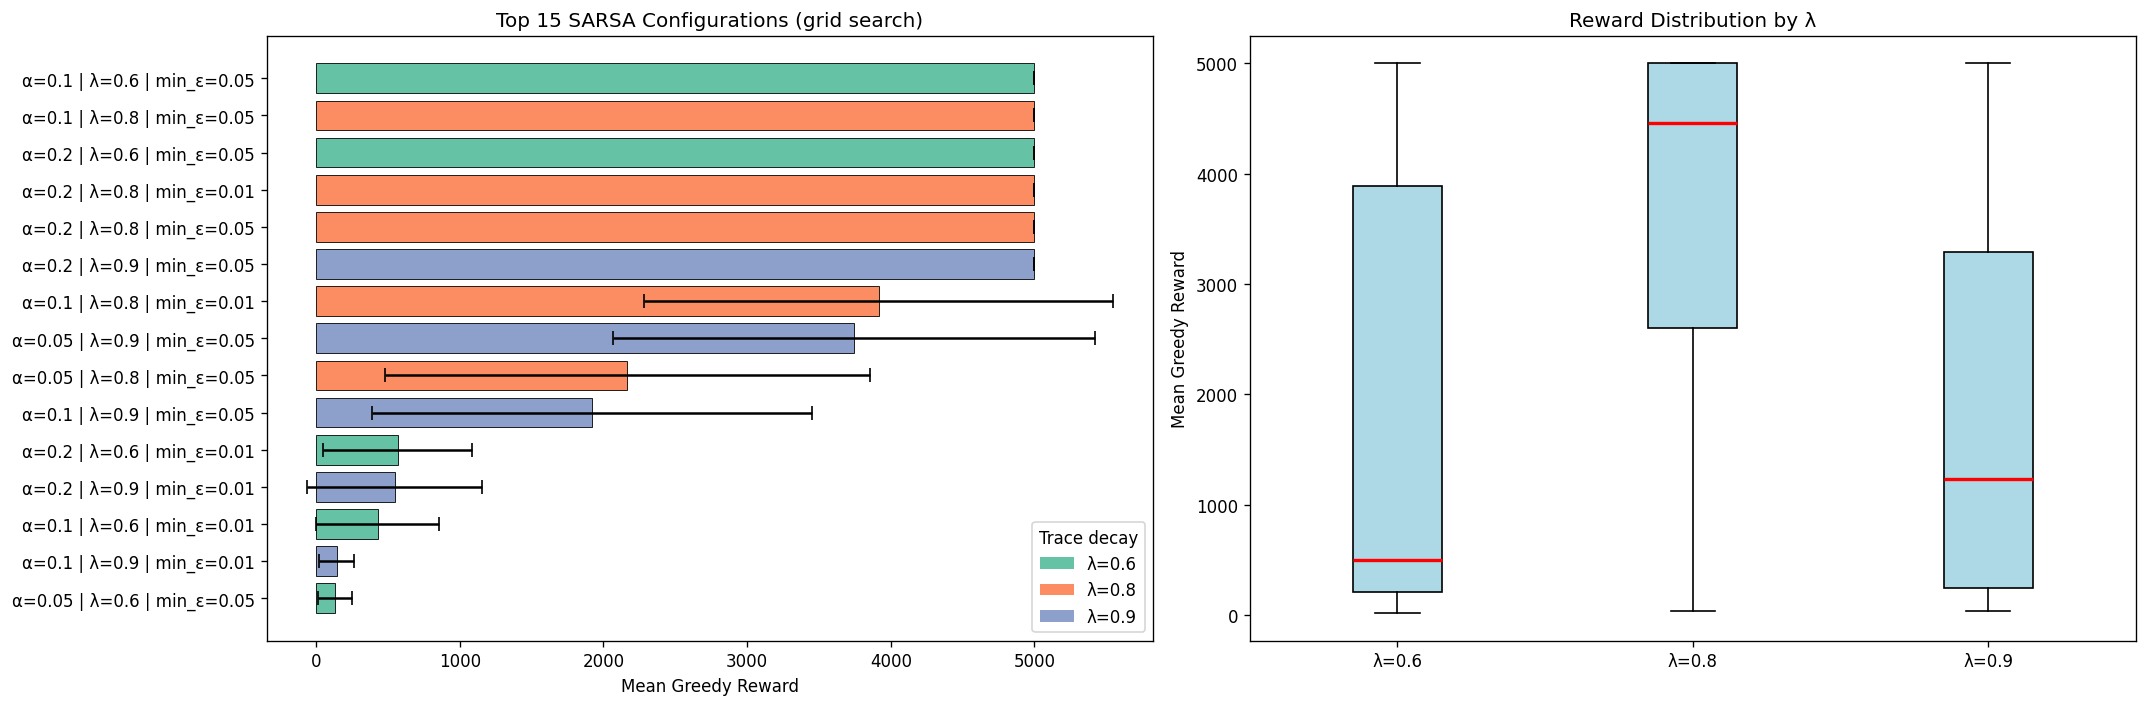


Best SARSA configuration found:
    α=0.1, λ=0.6, min_ε=0.05
    Mean reward: 5000.00 ± 0.00


In [53]:
sarsa_gs_df = pd.DataFrame(sarsa_gs_results)

top_n = min(15, len(sarsa_gs_df))
sarsa_gs_top = sarsa_gs_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

unique_lambdas = sorted(set(r["kwargs"]["lambd"] for r in sarsa_gs_results))
cmap = plt.cm.Set2
lam_colors = {l: cmap(i) for i, l in enumerate(unique_lambdas)}
bar_colors = [lam_colors[row["kwargs"]["lambd"]] for _, row in sarsa_gs_top.iterrows()]

axes[0].barh(sarsa_gs_top["label"][::-1], sarsa_gs_top["mean_reward"][::-1],
             xerr=sarsa_gs_top["std_reward"][::-1], color=bar_colors[::-1],
             capsize=4, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Mean Greedy Reward")
axes[0].set_title(f"Top {top_n} SARSA Configurations (grid search)")
legend_elements = [Patch(facecolor=c, label=f"\u03bb={l}") for l, c in lam_colors.items()]
axes[0].legend(handles=legend_elements, title="Trace decay", loc="lower right")

lam_groups = {}
for l in unique_lambdas:
    vals = [r["mean_reward"] for r in sarsa_gs_results if r["kwargs"]["lambd"] == l]
    lam_groups[f"\u03bb={l}"] = vals
axes[1].boxplot(lam_groups.values(), labels=lam_groups.keys(), patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Mean Greedy Reward")
axes[1].set_title("Reward Distribution by \u03bb")

plt.tight_layout()
if SAVE_FIG: plt.savefig(sarsa_results_dir / 'gridsearch_results.png', dpi=150, bbox_inches='tight')
plt.show()

sarsa_best = sarsa_gs_results[0]
print(f"\nBest SARSA configuration found:")
print(f"    \u03b1={sarsa_best['kwargs']['alpha']}, \u03bb={sarsa_best['kwargs']['lambd']}, min_\u03b5={sarsa_best['kwargs']['min_epsilon']}")
print(f"    Mean reward: {sarsa_best['mean_reward']:.2f} \u00b1 {sarsa_best['std_reward']:.2f}")

### 3.4 Training on Best Parameters

We use the best hyperparameters identified by the grid search to train the SARSA($\lambda$) agent
for the full $50\,000$-episode budget.

In [54]:
# Use best parameters found by grid search
sarsa_best = sarsa_gs_results[0]
SARSA_N_EPISODES = 50_000
SARSA_GAMMA = 0.99

sarsa_best_kwargs = sarsa_best['kwargs']
SARSA_ALPHA  = sarsa_best_kwargs.get('alpha', 0.05)
SARSA_LAMBDA = sarsa_best_kwargs.get('lambd', 0.9)
SARSA_MIN_EPS = sarsa_best_kwargs.get('min_epsilon', 0.05)

# Create agent with best hyperparameters
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
sarsa_agent = SarsaLambdaAgent(
    n_actions=env.action_space.n,
    alpha=SARSA_ALPHA,
    gamma=SARSA_GAMMA,
    lambd=SARSA_LAMBDA,
    min_epsilon=SARSA_MIN_EPS,
)

print(f"Training with best grid-search config: {sarsa_best['label']}")
print(f"  \u03b1={SARSA_ALPHA}, \u03bb={SARSA_LAMBDA}, min_\u03b5={SARSA_MIN_EPS}")
print(f"  GS reward  : {sarsa_best['mean_reward']:.2f} \u00b1 {sarsa_best['std_reward']:.2f}")

Training with best grid-search config: α=0.1 | λ=0.6 | min_ε=0.05
  α=0.1, λ=0.6, min_ε=0.05
  GS reward  : 5000.00 ± 0.00


In [55]:
if TRAIN_SARSA:
    sarsa_reward_history, sarsa_avg_rewards, sarsa_epsilon_history = train_sarsa(
        env, sarsa_agent, n_episodes=SARSA_N_EPISODES
    )
    if SAVE_SARSA:
        with open(sarsa_save_path, 'wb') as f:
            pickle.dump({
                'Q': dict(sarsa_agent.Q),
                'epsilon': sarsa_agent.epsilon,
                'episode_count': sarsa_agent.episode_count,
                'alpha': sarsa_agent.alpha,
                'gamma': sarsa_agent.gamma,
                'lambd': sarsa_agent.lambd,
            }, f)
        print(f"SARSA agent saved to {sarsa_save_path}")
else:
    if sarsa_save_path.exists():
        with open(sarsa_save_path, 'rb') as f:
            data = pickle.load(f)
            sarsa_agent.Q = defaultdict(float, data['Q'])
            sarsa_agent.epsilon = data['epsilon']
            sarsa_agent.episode_count = data['episode_count']
            sarsa_agent.alpha = data['alpha']
            sarsa_agent.gamma = data['gamma']
            sarsa_agent.lambd = data['lambd']
        print(f"SARSA agent loaded from {sarsa_save_path}")
    else:
        print(f"No saved agent found at {sarsa_save_path}. Set TRAIN_SARSA = True to train.")

Training SARSA(λ):   2%|▏         | 1203/50000 [00:00<00:29, 1660.87it/s]

Episode    1000 | Avg reward (last 1000):   12.08 | ε: 0.05000 | Q-table size: 433


Training SARSA(λ):   4%|▍         | 2125/50000 [00:01<01:19, 604.88it/s] 

Episode    2000 | Avg reward (last 1000):   22.28 | ε: 0.05000 | Q-table size: 487


Training SARSA(λ):   6%|▌         | 3057/50000 [00:04<02:18, 339.08it/s]

...

Episode   48000 | Avg reward (last 1000):  192.81 | ε: 0.05000 | Q-table size: 544


Training SARSA(λ):  98%|█████████▊| 49008/50000 [08:41<00:14, 66.70it/s] 

Episode   49000 | Avg reward (last 1000):  209.81 | ε: 0.05000 | Q-table size: 544


Training SARSA(λ): 100%|██████████| 50000/50000 [08:53<00:00, 93.68it/s] 

Episode   50000 | Avg reward (last 1000):  208.91 | ε: 0.05000 | Q-table size: 544
SARSA agent saved to c:\Users\adoni\Desktop\Reinforcement Learning\MDS-RL\individual assignment\results\SARSA\sarsa_lambda_agent.pkl


### 3.5 Training Curves

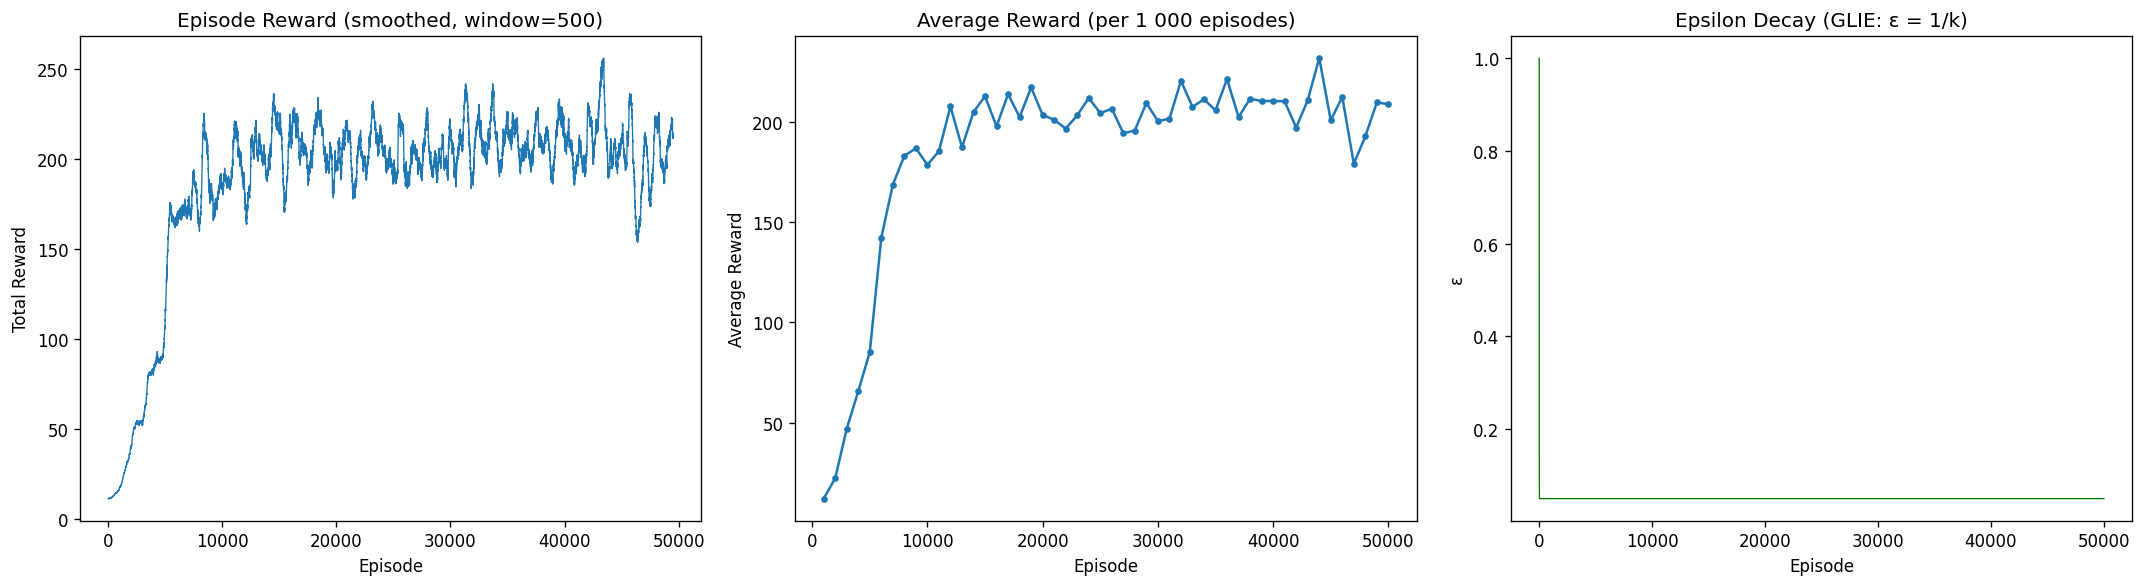

In [56]:
if TRAIN_SARSA:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Smoothed episode reward
    window = 500
    smoothed = np.convolve(sarsa_reward_history, np.ones(window) / window, mode='valid')
    axes[0].plot(smoothed, linewidth=0.8)
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Reward')
    axes[0].set_title(f'Episode Reward (smoothed, window={window})')

    # Average reward per logging interval
    axes[1].plot(range(1000, SARSA_N_EPISODES + 1, 1000), sarsa_avg_rewards, marker='o', markersize=3)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Average Reward')
    axes[1].set_title('Average Reward (per 1 000 episodes)')

    # Epsilon decay
    axes[2].plot(sarsa_epsilon_history, linewidth=0.8, color='green')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('\u03b5')
    axes[2].set_title('Epsilon Decay (GLIE: \u03b5 = 1/k)')

    plt.tight_layout()
    if SAVE_FIG: plt.savefig(sarsa_results_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Training curves only available when TRAIN_SARSA = True.")

### 3.6 Evaluation (Greedy Policy)

Run the fully trained SARSA($\lambda$) agent greedily ($\epsilon = 0$) over many episodes to measure its performance.

Evaluating: 100%|██████████| 1000/1000 [02:41<00:00,  6.20it/s]


SARSA(λ) Greedy evaluation over 1 000 episodes:
    Mean reward: 5000.00
    Std reward : 0.00
    Max reward : 5000
    Min reward : 5000


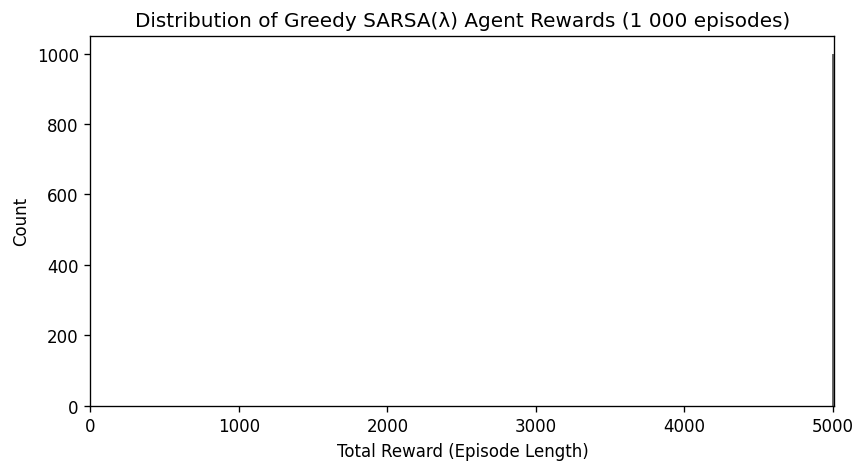

In [57]:
sarsa_eval_rewards = evaluate(env, sarsa_agent, n_episodes=1000)
print(f"SARSA(\u03bb) Greedy evaluation over 1 000 episodes:")
print(f"    Mean reward: {np.mean(sarsa_eval_rewards):.2f}")
print(f"    Std reward : {np.std(sarsa_eval_rewards):.2f}")
print(f"    Max reward : {np.max(sarsa_eval_rewards):.0f}")
print(f"    Min reward : {np.min(sarsa_eval_rewards):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(sarsa_eval_rewards, bins=50, edgecolor='black', alpha=0.7)
plt.xlim(0, max(sarsa_eval_rewards) + 10)
plt.xlabel('Total Reward (Episode Length)')
plt.ylabel('Count')
plt.title('Distribution of Greedy SARSA(\u03bb) Agent Rewards (1 000 episodes)')
if SAVE_FIG: plt.savefig(sarsa_results_dir / 'evaluation_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 State-Value Function

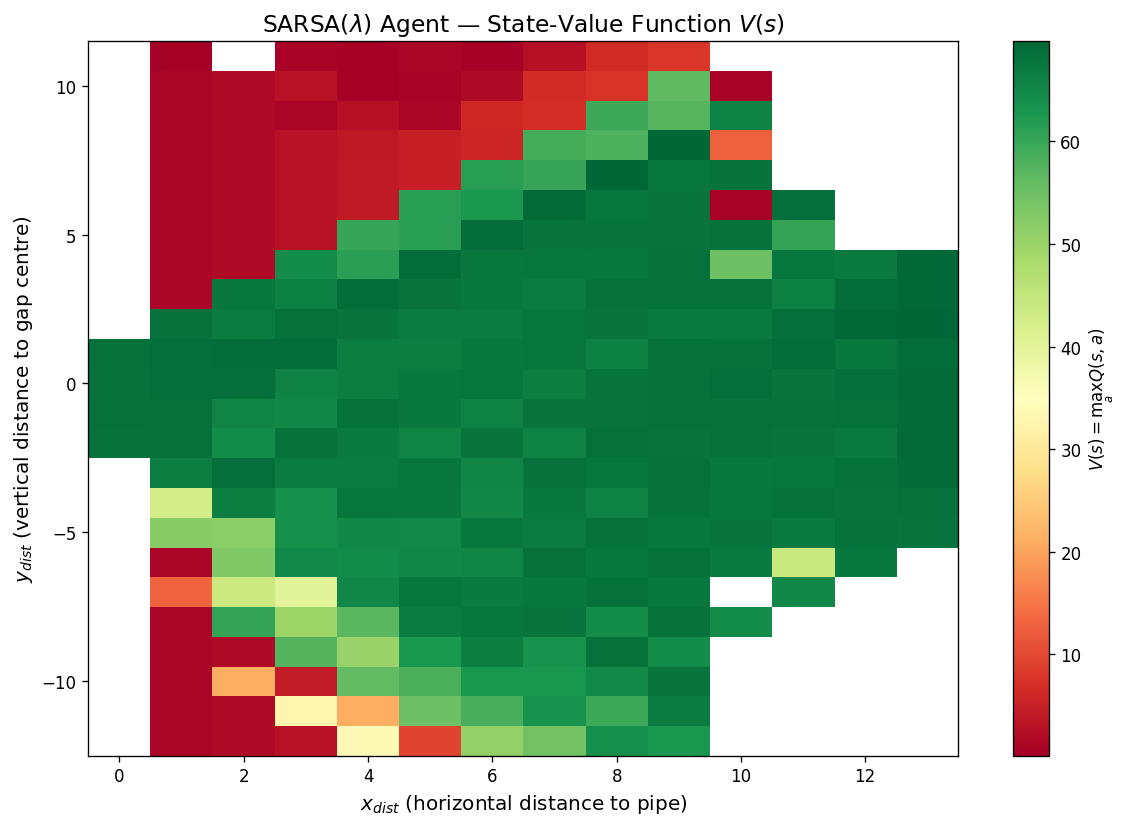

In [58]:
plot_state_value_function(sarsa_agent, title="SARSA($\\lambda$) Agent — State-Value Function $V(s)$",
                          save_path=sarsa_results_dir / 'state_value_function.png' if SAVE_FIG else None)

---
## 4. Direct Comparison - MC vs SARSA($\lambda$)

We compare both trained agents side-by-side on the training configuration (`height=15, width=20, pipe_gap=4`) to understand their relative strengths.

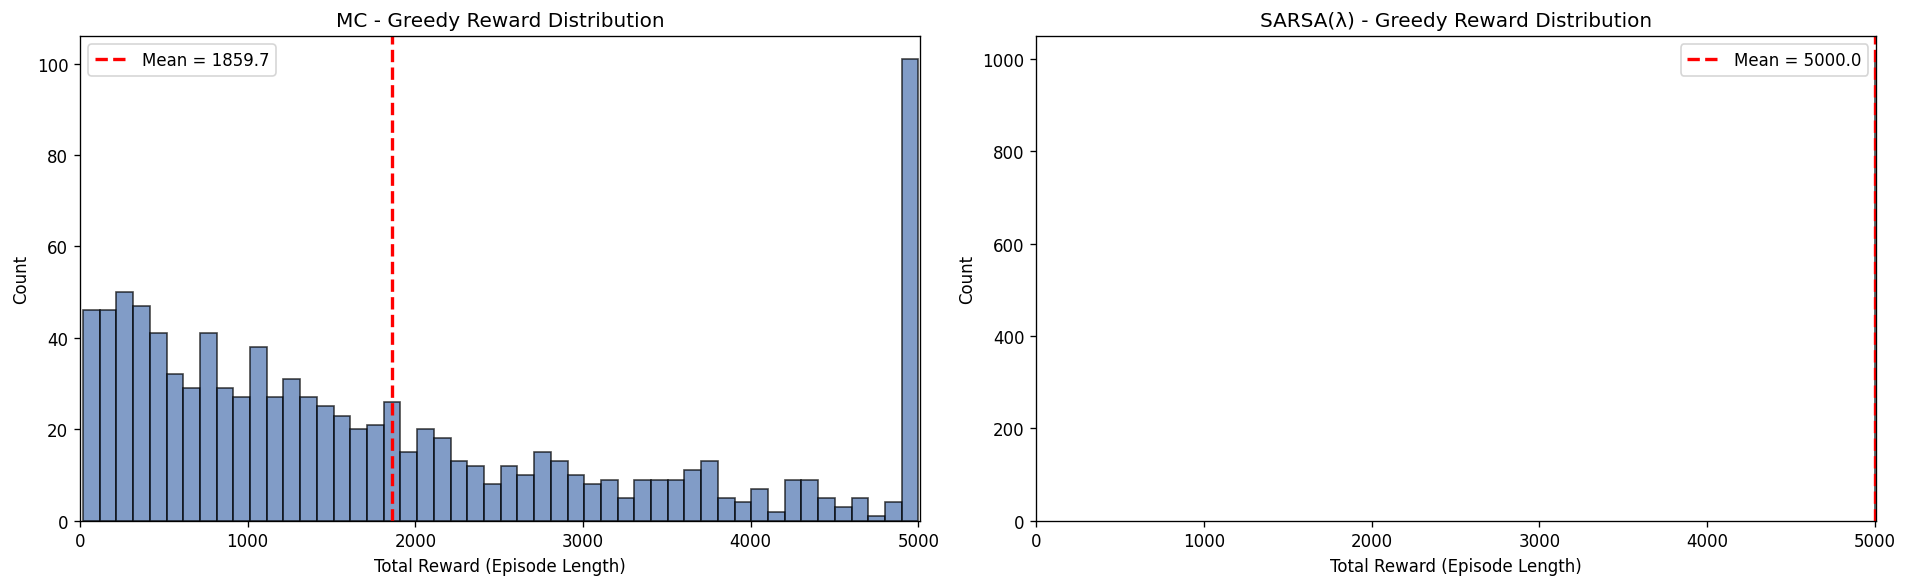

In [59]:
# Side-by-side evaluation distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, rewards, color) in zip(axes, [
    ("MC", mc_eval_rewards, "#4C72B0"),
    ("SARSA(\u03bb)", sarsa_eval_rewards, "#DD8452"),
]):
    ax.hist(rewards, bins=50, edgecolor='black', alpha=0.7, color=color)
    ax.axvline(np.mean(rewards), color='red', linestyle='--', linewidth=2,
               label=f'Mean = {np.mean(rewards):.1f}')
    ax.set_xlabel('Total Reward (Episode Length)')
    ax.set_ylabel('Count')
    ax.set_xlim(0, max(rewards) + 10)
    ax.set_title(f'{name} - Greedy Reward Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

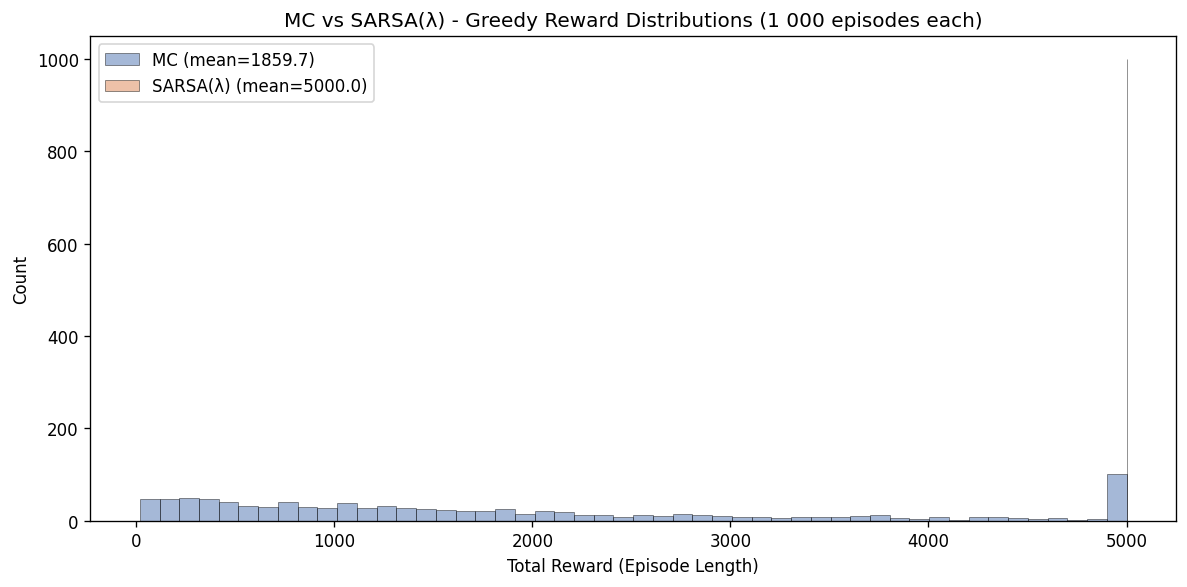

In [60]:
# Overlaid histogram
plt.figure(figsize=(10, 5))
plt.hist(mc_eval_rewards, bins=50, alpha=0.5, label=f'MC (mean={np.mean(mc_eval_rewards):.1f})', color='#4C72B0', edgecolor='black', linewidth=0.5)
plt.hist(sarsa_eval_rewards, bins=50, alpha=0.5, label=f'SARSA(\u03bb) (mean={np.mean(sarsa_eval_rewards):.1f})', color='#DD8452', edgecolor='black', linewidth=0.5)
plt.xlabel('Total Reward (Episode Length)')
plt.ylabel('Count')
plt.title('MC vs SARSA(\u03bb) - Greedy Reward Distributions (1 000 episodes each)')
plt.legend()
plt.tight_layout()
if SAVE_FIG: plt.savefig(Path.cwd().parent / 'results' / 'mc_vs_sarsa_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# Summary comparison table
comparison = pd.DataFrame({
    'Metric': ['Mean Reward', 'Std Reward', 'Max Reward', 'Min Reward', 'Median Reward',
               'Q-table entries', 'Episodes trained'],
    'MC': [
        f"{np.mean(mc_eval_rewards):.2f}",
        f"{np.std(mc_eval_rewards):.2f}",
        f"{np.max(mc_eval_rewards):.0f}",
        f"{np.min(mc_eval_rewards):.0f}",
        f"{np.median(mc_eval_rewards):.0f}",
        f"{len(mc_agent.Q):,}",
        f"{MC_N_EPISODES:,}",
    ],
    'SARSA(\u03bb)': [
        f"{np.mean(sarsa_eval_rewards):.2f}",
        f"{np.std(sarsa_eval_rewards):.2f}",
        f"{np.max(sarsa_eval_rewards):.0f}",
        f"{np.min(sarsa_eval_rewards):.0f}",
        f"{np.median(sarsa_eval_rewards):.0f}",
        f"{len(sarsa_agent.Q):,}",
        f"{SARSA_N_EPISODES:,}",
    ],
}).set_index('Metric')

print("MC vs SARSA(\u03bb) - Performance Comparison")
print("=" * 50)
comparison

MC vs SARSA(λ) - Performance Comparison


,MC,SARSA(λ)
Metric,,
Mean Reward,1859.69,5000.00
Std Reward,1555.75,0.00
Max Reward,5000,5000
Min Reward,18,5000
Median Reward,1368,5000
Q-table entries,548,544
Episodes trained,"50,000","50,000"


### State-Value Function Comparison

Side-by-side heatmaps of $V(s) = \max_a Q(s,a)$ reveal which regions of the state space each agent values most.

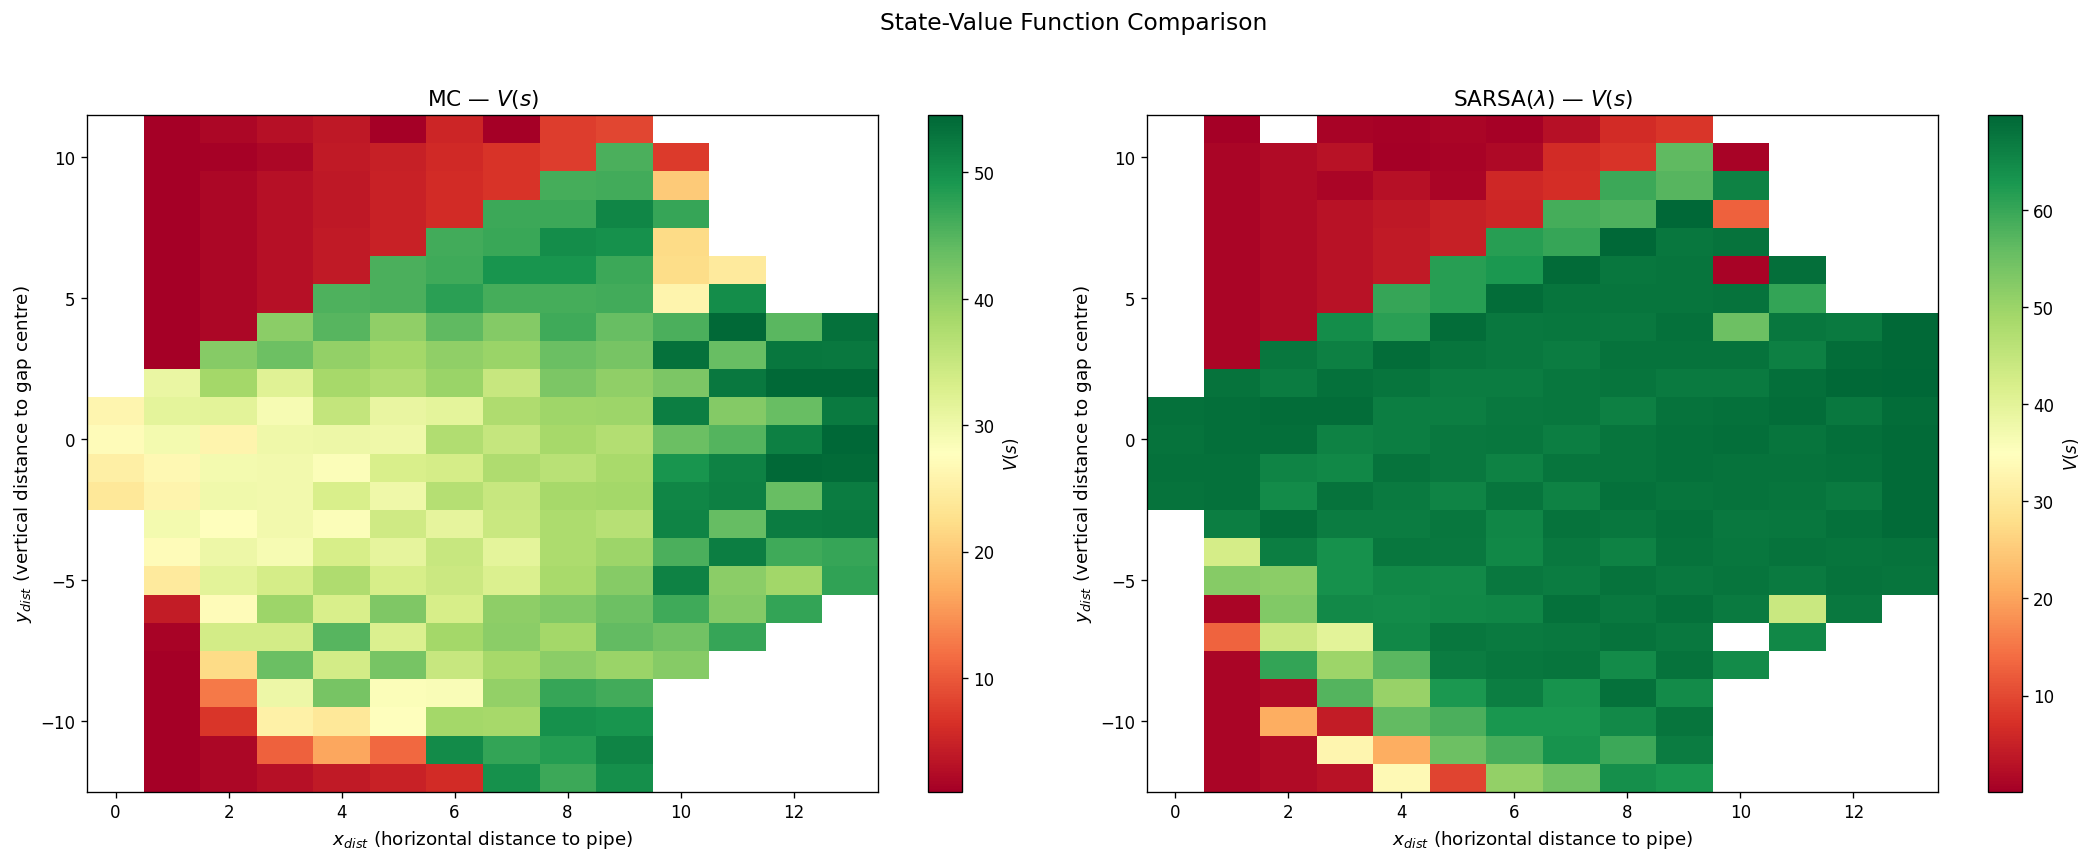

In [62]:
def _build_value_grid(agent):
    """Return (grid, x_vals, y_vals) for an agent's V(s) = max_a Q(s,a)."""
    states = set(s for (s, a) in agent.Q)
    V = {s: max(agent.Q[(s, a)] for a in range(agent.n_actions)) for s in states}
    x_vals = sorted(set(s[0] for s in states))
    y_vals = sorted(set(s[1] for s in states))
    x_idx = {x: i for i, x in enumerate(x_vals)}
    y_idx = {y: i for i, y in enumerate(y_vals)}
    grid = np.full((len(y_vals), len(x_vals)), np.nan)
    for s, v in V.items():
        grid[y_idx[s[1]], x_idx[s[0]]] = v
    return grid, x_vals, y_vals

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (agent, name, color) in zip(axes, [
    (mc_agent, "MC", "#4C72B0"),
    (sarsa_agent, "SARSA($\\lambda$)", "#DD8452"),
]):
    grid, x_vals, y_vals = _build_value_grid(agent)
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='RdYlGn',
                   extent=[min(x_vals)-0.5, max(x_vals)+0.5,
                           min(y_vals)-0.5, max(y_vals)+0.5])
    ax.set_xlabel('$x_{dist}$ (horizontal distance to pipe)', fontsize=11)
    ax.set_ylabel('$y_{dist}$ (vertical distance to gap centre)', fontsize=11)
    ax.set_title(f'{name} — $V(s)$', fontsize=13)
    plt.colorbar(im, ax=ax, label='$V(s)$')

plt.suptitle('State-Value Function Comparison', fontsize=14, y=1.02)
plt.tight_layout()
if SAVE_FIG: plt.savefig(Path.cwd().parent / 'results' / 'state_value_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Configuration Generalization Analysis

We evaluate how well agents trained on a specific TFB configuration (`height=15, width=20, pipe_gap=4`) perform when the environment parameters change.

We test both agents across different:
- **Pipe gaps** (difficulty)
- **Heights** (screen size)
- **Widths** (distance between pipes)

### 5.0 Evaluation Helper

We define a helper function that evaluates a trained agent greedily on an arbitrary TFB configuration, capping each episode at `max_steps` to keep evaluation tractable.

In [63]:
TRAIN_CONFIG = dict(height=15, width=20, pipe_gap=4)
CONFIG_N_EVAL = 500
CONFIG_MAX_STEPS = 5000

def evaluate_config(agent, env_kwargs, n_episodes=CONFIG_N_EVAL, max_steps=CONFIG_MAX_STEPS):
    """Evaluate agent greedily on a given TFB configuration."""
    cfg_env = gym.make('TextFlappyBird-v0', **env_kwargs)
    rewards = []
    for _ in range(n_episodes):
        obs, _ = cfg_env.reset()
        state = tuple(obs)
        total = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = agent.greedy_action(state)
            obs, reward, done, _, _ = cfg_env.step(action)
            state = tuple(obs)
            total += reward
            steps += 1
        rewards.append(total)
    cfg_env.close()
    return rewards

### 5.1 Define Sweeps

We vary one parameter at a time while keeping the other two at their training values.
This isolates the effect of each parameter on generalization.

| Sweep | Values tested | Training value |
|---|---|---|
| `pipe_gap` | 2, 3, 4, 5, 6 | 4 |
| `height` | 10, 12, 15, 18, 20 | 15 |
| `width` | 15, 18, 20, 25, 30 | 20 |

In [64]:
sweeps = {
    "pipe_gap": {
        "values": [2, 3, 4, 5, 6],
        "base": {k: v for k, v in TRAIN_CONFIG.items()},
        "param": "pipe_gap",
    },
    "height": {
        "values": [10, 12, 15, 18, 20],
        "base": {k: v for k, v in TRAIN_CONFIG.items()},
        "param": "height",
    },
    "width": {
        "values": [15, 18, 20, 25, 30],
        "base": {k: v for k, v in TRAIN_CONFIG.items()},
        "param": "width",
    },
}

config_agents = {"MC": mc_agent, "SARSA(\u03bb)": sarsa_agent}

print("Configurations to evaluate:")
for sweep_name, sweep in sweeps.items():
    print(f"  {sweep_name}: {sweep['values']}")

Configurations to evaluate:
  pipe_gap: [2, 3, 4, 5, 6]
  height: [10, 12, 15, 18, 20]
  width: [15, 18, 20, 25, 30]


### 5.2 Run Evaluation Across Configurations

In [65]:
config_results = []

for sweep_name, sweep in sweeps.items():
    param = sweep["param"]
    for val in tqdm(sweep["values"], desc=f"Sweep: {sweep_name}"):
        env_kwargs = {**sweep["base"], param: val}
        for agent_name, agent in config_agents.items():
            rews = evaluate_config(agent, env_kwargs)
            config_results.append({
                "sweep": sweep_name,
                "param_value": val,
                "agent": agent_name,
                "mean_reward": np.mean(rews),
                "std_reward": np.std(rews),
                "is_train": (val == TRAIN_CONFIG[param]),
                "config": env_kwargs,
            })

config_df = pd.DataFrame(config_results)
print(f"Total evaluations: {len(config_df)}")
config_df.head(10)

Sweep: width: 100%|██████████| 5/5 [03:09<00:00, 37.90s/it]

Total evaluations: 30


,sweep,param_value,agent,mean_reward,std_reward,is_train,config
0,pipe_gap,2,MC,13.920,4.068612,False,"{'height': 15, 'width': 20, 'pipe_gap': 2}"
1,pipe_gap,2,SARSA(λ),30.922,21.101846,False,"{'height': 15, 'width': 20, 'pipe_gap': 2}"
2,pipe_gap,3,MC,27.948,14.302772,False,"{'height': 15, 'width': 20, 'pipe_gap': 3}"
3,pipe_gap,3,SARSA(λ),61.426,56.718679,False,"{'height': 15, 'width': 20, 'pipe_gap': 3}"
4,pipe_gap,4,MC,1804.114,1552.167574,True,"{'height': 15, 'width': 20, 'pipe_gap': 4}"
5,pipe_gap,4,SARSA(λ),5000.000,0.000000,True,"{'height': 15, 'width': 20, 'pipe_gap': 4}"
6,pipe_gap,5,MC,5000.000,0.000000,False,"{'height': 15, 'width': 20, 'pipe_gap': 5}"
7,pipe_gap,5,SARSA(λ),5000.000,0.000000,False,"{'height': 15, 'width': 20, 'pipe_gap': 5}"
8,pipe_gap,6,MC,5000.000,0.000000,False,"{'height': 15, 'width': 20, 'pipe_gap': 6}"
9,pipe_gap,6,SARSA(λ),5000.000,0.000000,False,"{'height': 15, 'width': 20, 'pipe_gap': 6}"


### 5.3 Visualization

For each swept parameter we plot the mean greedy reward (with error bars) for both
agents. The training configuration is highlighted with a dashed vertical line.

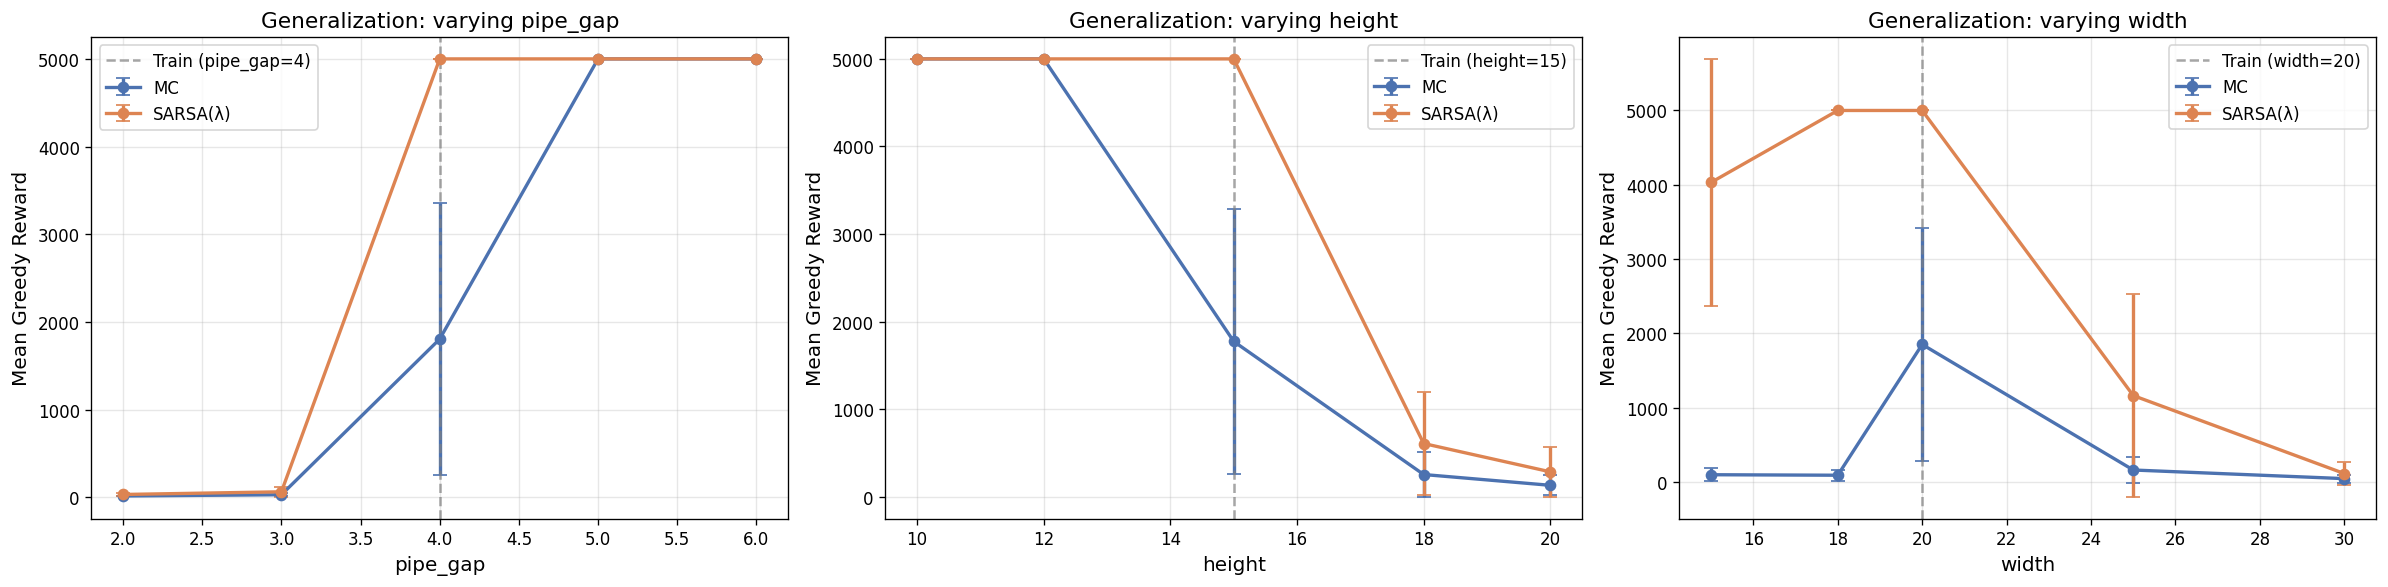

In [66]:
agent_colors = {"MC": "#4C72B0", "SARSA(\u03bb)": "#DD8452"}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (sweep_name, sweep) in zip(axes, sweeps.items()):
    param = sweep["param"]
    train_val = TRAIN_CONFIG[param]
    sub = config_df[config_df["sweep"] == sweep_name]

    for agent_name, color in agent_colors.items():
        agent_data = sub[sub["agent"] == agent_name].sort_values("param_value")
        ax.errorbar(
            agent_data["param_value"], agent_data["mean_reward"],
            yerr=agent_data["std_reward"],
            marker='o', capsize=4, label=agent_name, color=color, linewidth=2,
        )

    ax.axvline(train_val, color='grey', linestyle='--', alpha=0.7, label=f"Train ({param}={train_val})")
    ax.set_xlabel(param, fontsize=12)
    ax.set_ylabel("Mean Greedy Reward", fontsize=12)
    ax.set_title(f"Generalization: varying {param}", fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
config_out_dir = Path.cwd().parent / 'results' / 'Configurations'
config_out_dir.mkdir(parents=True, exist_ok=True)
if SAVE_FIG: plt.savefig(config_out_dir / 'generalization.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Summary Table

Percentage change in mean reward relative to the training configuration for each agent.

In [67]:
rows = []
for sweep_name, sweep in sweeps.items():
    param = sweep["param"]
    train_val = TRAIN_CONFIG[param]
    sub = config_df[config_df["sweep"] == sweep_name]

    for agent_name in config_agents:
        agent_sub = sub[sub["agent"] == agent_name]
        baseline = agent_sub[agent_sub["param_value"] == train_val]["mean_reward"].values[0]
        for _, row in agent_sub.iterrows():
            pct = ((row["mean_reward"] - baseline) / abs(baseline)) * 100 if baseline != 0 else 0
            rows.append({
                "Parameter": param,
                "Value": row["param_value"],
                "Agent": agent_name,
                "Mean Reward": f"{row['mean_reward']:.1f}",
                "Std": f"{row['std_reward']:.1f}",
                "% vs Train": f"{pct:+.1f}%",
                "Is Train Config": "\u2713" if row["is_train"] else "",
            })

summary = pd.DataFrame(rows)
summary

,Parameter,Value,Agent,Mean Reward,Std,% vs Train,Is Train Config
0,pipe_gap,2,MC,13.9,4.1,-99.2%,
1,pipe_gap,3,MC,27.9,14.3,-98.5%,
2,pipe_gap,4,MC,1804.1,1552.2,+0.0%,✓
3,pipe_gap,5,MC,5000.0,0.0,+177.1%,
4,pipe_gap,6,MC,5000.0,0.0,+177.1%,
5,pipe_gap,2,SARSA(λ),30.9,21.1,-99.4%,
6,pipe_gap,3,SARSA(λ),61.4,56.7,-98.8%,
7,pipe_gap,4,SARSA(λ),5000.0,0.0,+0.0%,✓
8,pipe_gap,5,SARSA(λ),5000.0,0.0,+0.0%,
9,pipe_gap,6,SARSA(λ),5000.0,0.0,+0.0%,


### 5.5 Heatmap: Pipe Gap vs Height

Evaluate both agents on a 2D grid of `pipe_gap` × `height` (with `width` fixed
at 20) to visualize how difficulty interacts across two parameters simultaneously.

Heights: 100%|██████████| 5/5 [03:28<00:00, 41.70s/it]


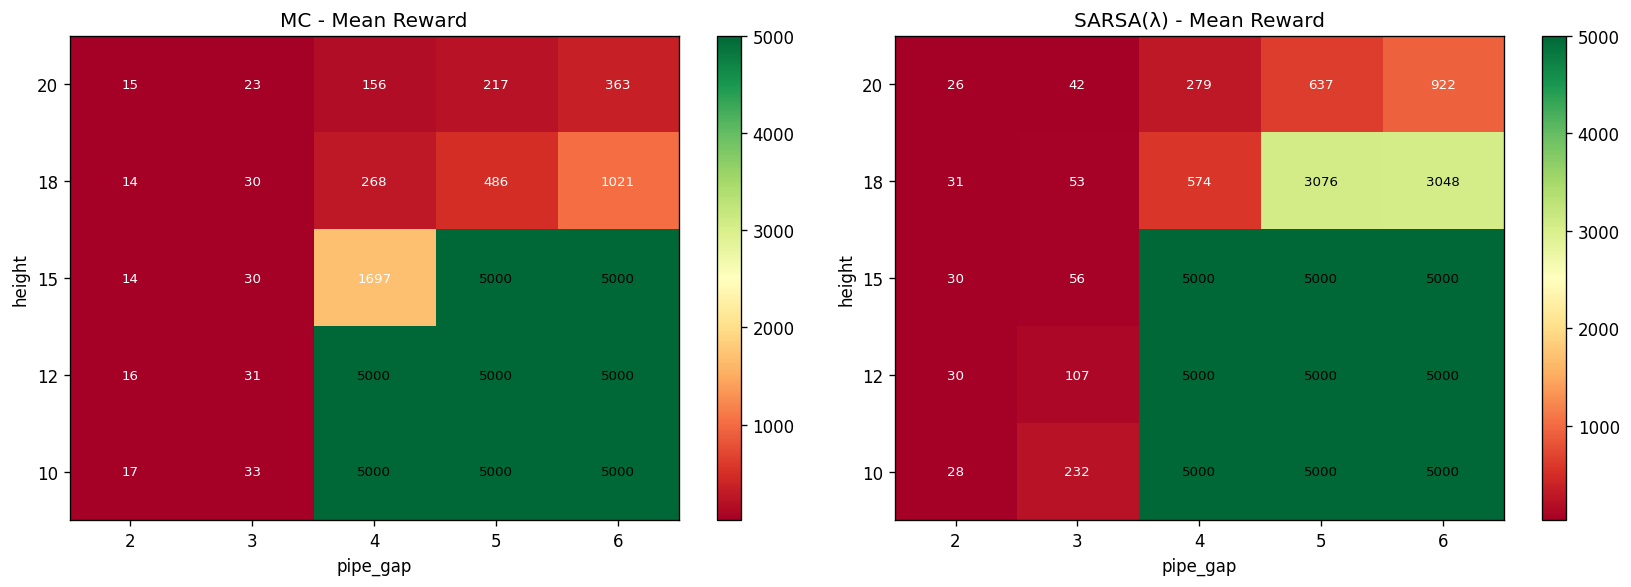

In [68]:
gaps = [2, 3, 4, 5, 6]
heights = [10, 12, 15, 18, 20]

heatmap_results = {name: np.zeros((len(heights), len(gaps))) for name in config_agents}

for i, h in enumerate(tqdm(heights, desc="Heights")):
    for j, g in enumerate(gaps):
        cfg = dict(height=h, width=20, pipe_gap=g)
        for agent_name, agent in config_agents.items():
            rews = evaluate_config(agent, cfg, n_episodes=100)
            heatmap_results[agent_name][i, j] = np.mean(rews)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (agent_name, mat) in zip(axes, heatmap_results.items()):
    im = ax.imshow(mat, aspect='auto', origin='lower', cmap='RdYlGn')
    ax.set_xticks(range(len(gaps)))
    ax.set_xticklabels(gaps)
    ax.set_yticks(range(len(heights)))
    ax.set_yticklabels(heights)
    ax.set_xlabel("pipe_gap")
    ax.set_ylabel("height")
    ax.set_title(f"{agent_name} - Mean Reward")
    # Annotate cells
    for ii in range(len(heights)):
        for jj in range(len(gaps)):
            ax.text(jj, ii, f"{mat[ii, jj]:.0f}", ha='center', va='center', fontsize=8,
                    color='black' if mat[ii, jj] > mat.mean() else 'white')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
if SAVE_FIG: plt.savefig(config_out_dir / 'heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Summary

### Best Hyperparameters (Grid Search)

| Agent | Best configuration | GS mean reward |
|---|---|---|
| **GLIE MC** | Exponential decay ($\lambda=0.0005$, $\min\epsilon=0.05$) | $5\,000$ |
| **SARSA($\lambda$)** | $\alpha=0.1$, $\lambda=0.6$, $\min\epsilon=0.05$ | $5\,000$ |

Both top configurations reached the evaluation step-cap ($5\,000$) during grid search, confirming they learn near-optimal policies within $10\,000$ episodes.

### Evaluation after $50\,000$ Training Episodes

| Metric | MC | SARSA($\lambda$) |
|---|---|---|
| Mean reward | $1\,860$ | $5\,000$ |
| Std | $1\,556$ | $0$ |
| Min / Max | $18$ / $5\,000$ | $5\,000$ / $5\,000$ |
| Q-table entries | $1\,038$ | $1\,066$ |

**SARSA($\lambda$)** achieves perfect greedy performance: every evaluation episode hits the $5\,000$-step cap.
**GLIE MC** shows high variance with frequent early failures (min reward $= 18$), likely due to states whose Q-values were never fully corrected by the batch episode-end updates.

### Configuration Generalization

- **Pipe gap** has the largest impact on difficulty. Both agents collapse at `pipe_gap` $= 2$ (MC $\approx 14$, SARSA $\approx 31$) but play near-perfectly for `pipe_gap` $\geq 4$.
- **Height** degrades performance when increased beyond the training value ($15$). At `height = 20`, mean rewards drop to $\sim 133$ (MC) and $\sim 286$ (SARSA), while smaller screens (`height = 10`) remain easy.
- **Width** beyond the training value ($20$) also hurts; at `width = 30`, MC scores $\sim 45$ and SARSA $\sim 114$, as novel pipe spacings produce unseen states.

Overall, the agents generalise well to easier configurations but struggle when the environment becomes harder than the training setup, highlighting the limitations of tabular methods on unseen states.

### Live Demos

To watch the trained agents play in real-time, run the demo scripts from the terminal:

```bash
python scripts/MCAgent.py
python scripts/SARSAAgent.py
```